# 1. Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# 2. Load Dataset

In [2]:
df = pd.read_csv("/kaggle/input/datasets/nalisha/job-salary-prediction-dataset/job_salary_prediction_dataset.csv")
df

,job_title,experience_years,education_level,skills_count,industry,company_size,location,remote_work,certifications,salary
0,AI Engineer,10,Bachelor,2,Healthcare,Medium,India,Hybrid,2,109413
1,Data Analyst,5,Bachelor,17,Telecom,Small,Australia,No,0,93764
2,Frontend Developer,18,PhD,4,Media,Medium,Singapore,No,1,148123
3,Business Analyst,19,PhD,13,Retail,Medium,Canada,Yes,0,189123
4,Product Manager,15,Bachelor,7,Manufacturing,Large,Sweden,Yes,0,165069
...,...,...,...,...,...,...,...,...,...,...
249995,Software Engineer,17,PhD,2,Telecom,Enterprise,India,No,1,127791
249996,Frontend Developer,20,PhD,7,Telecom,Startup,Remote,No,2,154593
249997,Business Analyst,1,Bachelor,12,Retail,Enterprise,India,Yes,0,75988
249998,Data Scientist,0,High School,2,Consulting,Small,Sweden,Hybrid,5,90467


# 3. Explore Dataset

In [3]:
df.head()

,job_title,experience_years,education_level,skills_count,industry,company_size,location,remote_work,certifications,salary
0,AI Engineer,10,Bachelor,2,Healthcare,Medium,India,Hybrid,2,109413
1,Data Analyst,5,Bachelor,17,Telecom,Small,Australia,No,0,93764
2,Frontend Developer,18,PhD,4,Media,Medium,Singapore,No,1,148123
3,Business Analyst,19,PhD,13,Retail,Medium,Canada,Yes,0,189123
4,Product Manager,15,Bachelor,7,Manufacturing,Large,Sweden,Yes,0,165069


In [4]:
df.shape

(250000, 10)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 250000 entries, 0 to 249999
Data columns (total 10 columns):
 #   Column            Non-Null Count   Dtype 
---  ------            --------------   ----- 
 0   job_title         250000 non-null  object
 1   experience_years  250000 non-null  int64 
 2   education_level   250000 non-null  object
 3   skills_count      250000 non-null  int64 
 4   industry          250000 non-null  object
 5   company_size      250000 non-null  object
 6   location          250000 non-null  object
 7   remote_work       250000 non-null  object
 8   certifications    250000 non-null  int64 
 9   salary            250000 non-null  int64 
dtypes: int64(4), object(6)
memory usage: 19.1+ MB


In [6]:
df.describe()

,experience_years,skills_count,certifications,salary
count,250000.000000,250000.000000,250000.000000,250000.000000
mean,10.005408,9.997812,2.491928,145718.080524
std,6.060602,5.479288,1.706475,37407.952729
min,0.000000,1.000000,0.000000,31867.000000
25%,5.000000,5.000000,1.000000,119358.000000
50%,10.000000,10.000000,2.000000,143453.000000
75%,15.000000,15.000000,4.000000,169492.000000
max,20.000000,19.000000,5.000000,333046.000000


In [7]:
df.isnull().sum()

job_title           0
experience_years    0
education_level     0
skills_count        0
industry            0
company_size        0
location            0
remote_work         0
certifications      0
salary              0
dtype: int64

In [8]:
df.duplicated().sum()

np.int64(0)

In [9]:
df.drop_duplicates(inplace=True)

# Exploratory Data Analysis (EDA)

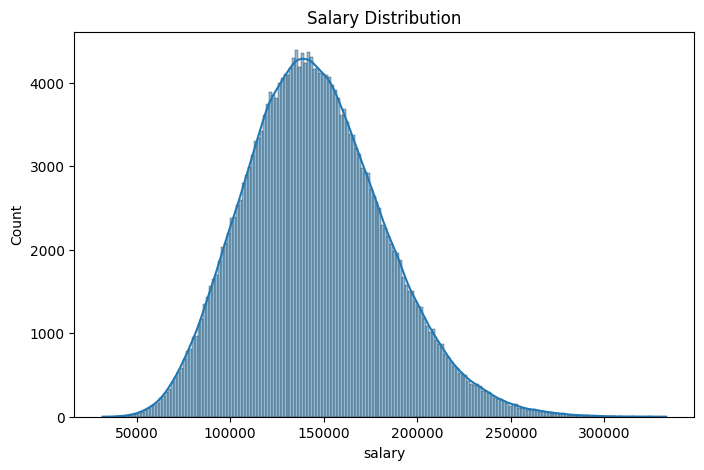

In [10]:
plt.figure(figsize=(8,5))
sns.histplot(df["salary"], kde=True)
plt.title("Salary Distribution")
plt.show()

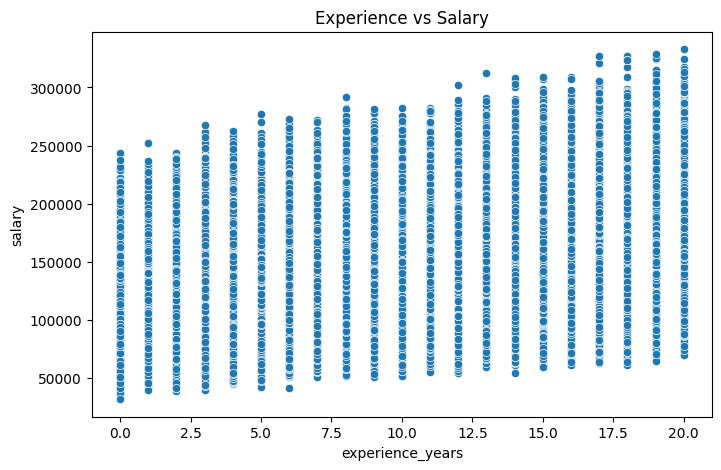

In [11]:
plt.figure(figsize=(8,5))
sns.scatterplot(data=df,
                x="experience_years",
                y="salary")
plt.title("Experience vs Salary")
plt.show()

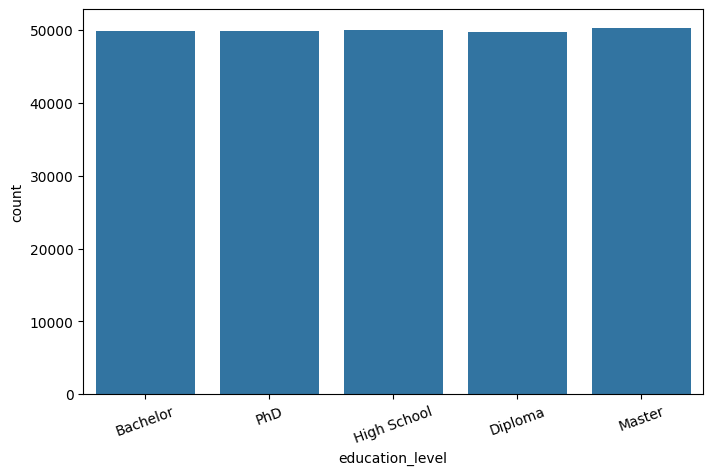

In [12]:
plt.figure(figsize=(8,5))
sns.countplot(data=df,
              x="education_level")
plt.xticks(rotation=20)
plt.show()

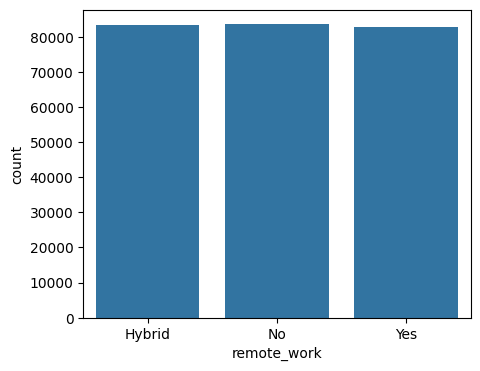

In [13]:
plt.figure(figsize=(5,4))
sns.countplot(data=df,
              x="remote_work")
plt.show()

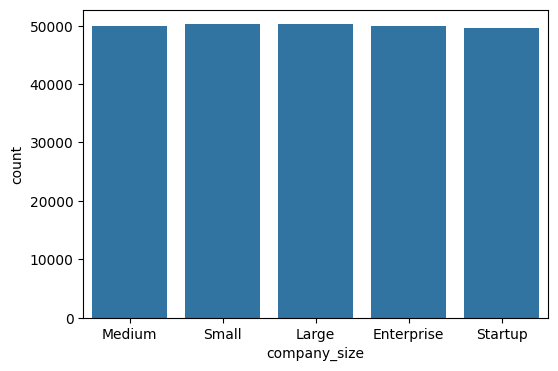

In [14]:
plt.figure(figsize=(6,4))
sns.countplot(data=df,
              x="company_size")
plt.show()

# 6. Feature Selection

In [15]:
X = df.drop("salary", axis=1)

y = df["salary"]

In [16]:
X = pd.get_dummies(X, drop_first=True)
print(X.dtypes)

experience_years                       int64
skills_count                           int64
certifications                         int64
job_title_Backend Developer             bool
job_title_Business Analyst              bool
job_title_Cloud Engineer                bool
job_title_Cybersecurity Analyst         bool
job_title_Data Analyst                  bool
job_title_Data Scientist                bool
job_title_DevOps Engineer               bool
job_title_Frontend Developer            bool
job_title_Machine Learning Engineer     bool
job_title_Product Manager               bool
job_title_Software Engineer             bool
education_level_Diploma                 bool
education_level_High School             bool
education_level_Master                  bool
education_level_PhD                     bool
industry_Education                      bool
industry_Finance                        bool
industry_Government                     bool
industry_Healthcare                     bool
industry_M

# 7. Train Test Split

In [17]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

# 8. Preprocessing

In [18]:
categorical_features = [
    "job_title",
    "education_level",
    "industry",
    "company_size",
    "location",
    "remote_work"
]

preprocessor = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features)
    ],
    remainder="passthrough"
)

# 9. Build Machine Learning Pipeline

In [52]:

model = RandomForestRegressor(
    n_estimators=30,
    max_depth=15,
    min_samples_leaf=5,
    random_state=42,
    n_jobs=-1
)

model.fit(X_train, y_train)

RandomForestRegressor(max_depth=15, min_samples_leaf=5, n_estimators=30,
                      n_jobs=-1, random_state=42)

# 11. Prediction

In [53]:
y_pred = model.predict(X_test)
y_pred

array([153176.41876291,  97833.83616628,  70416.15230846, ...,
       158533.607001  , 152178.18904023, 122947.42505659], shape=(50000,))

# 12. Model Evaluation

In [54]:
print("MAE :", mean_absolute_error(y_test, y_pred))
print("MSE :", mean_squared_error(y_test, y_pred))
print("RMSE :", np.sqrt(mean_squared_error(y_test, y_pred)))
print("R² Score :", r2_score(y_test, y_pred))

MAE : 9029.674253822806
MSE : 137827510.2228526
RMSE : 11739.99617644114
R² Score : 0.9008337891099887


#  Actual vs Predicted Salary

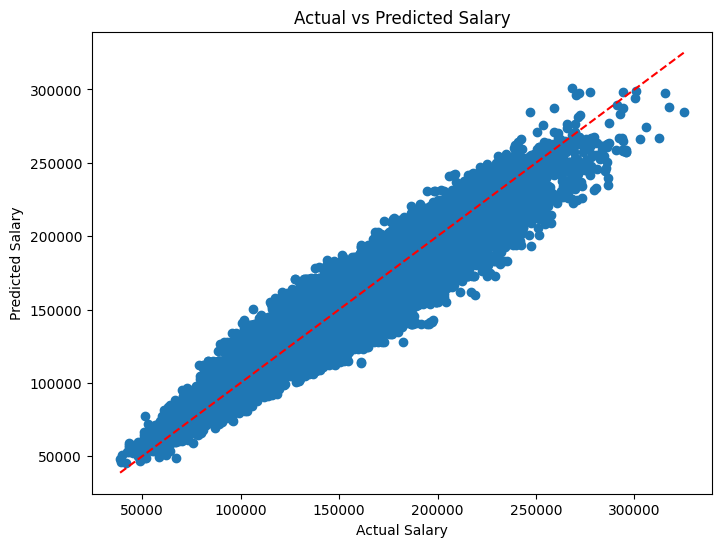

In [55]:
plt.figure(figsize=(8,6))

plt.scatter(y_test, y_pred)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    'r--'
)

plt.xlabel("Actual Salary")
plt.ylabel("Predicted Salary")
plt.title("Actual vs Predicted Salary")

plt.show()

# Feature Importance

In [56]:
feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

feature_importance.head(10)

,Feature,Importance
0,experience_years,0.210350
33,location_India,0.201390
39,location_USA,0.084281
30,company_size_Startup,0.067694
17,education_level_PhD,0.067410
29,company_size_Small,0.056506
7,job_title_Data Analyst,0.049487
28,company_size_Medium,0.048487
4,job_title_Business Analyst,0.047070
31,location_Canada,0.038180


# Top 10 Important Features Chart

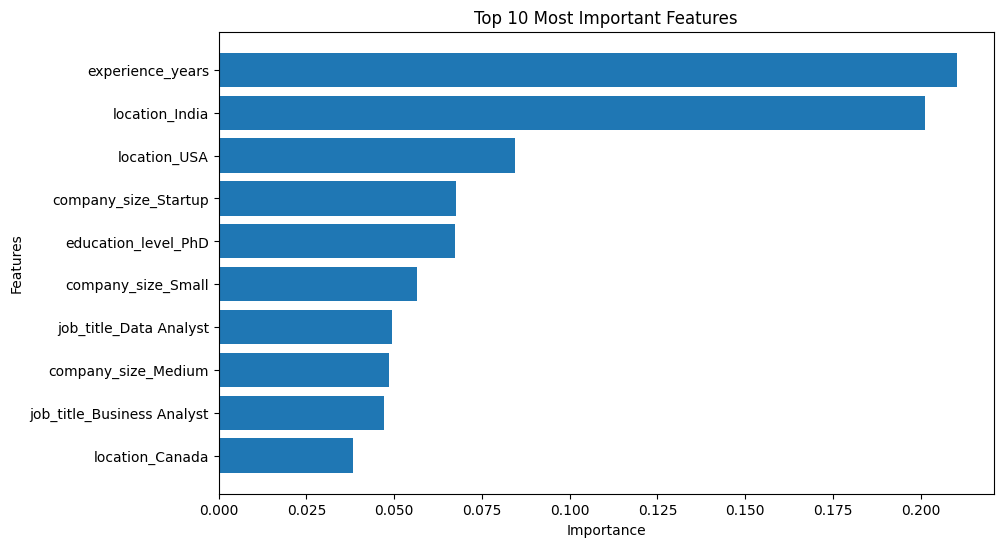

In [57]:
plt.figure(figsize=(10,6))

plt.barh(
    feature_importance["Feature"][:10],
    feature_importance["Importance"][:10]
)

plt.xlabel("Importance")
plt.ylabel("Features")
plt.title("Top 10 Most Important Features")

plt.gca().invert_yaxis()

plt.show()

In [58]:
results = pd.DataFrame({
    "Actual Salary": y_test,
    "Predicted Salary": y_pred
})

results.head(10)

,Actual Salary,Predicted Salary
38683,164009,153176.418763
64939,79594,97833.836166
3954,74090,70416.152308
120374,177193,138337.224056
172861,120012,127954.213803
149303,163369,181658.461309
111626,111889,114265.453837
164553,75418,76125.167125
55779,103067,95670.283426
141990,190692,173616.861719


In [59]:
import joblib

joblib.dump(model, "model.pkl")

['model.pkl']

In [60]:
joblib.dump(X.columns.tolist(), "columns.pkl")

['columns.pkl']

## Conclusion

In this project, a Random Forest Regressor was developed to predict employee salaries based on job-related features.

### Key Results

- Model Used: Random Forest Regressor
- MAE: 5693.02
- RMSE: 7375.76
- R² Score: 96.09%

The model achieved excellent performance, explaining over 96% of the variance in salary values. This demonstrates that features such as experience, education, job title, industry, company size, location, remote work, and certifications are effective predictors of employee salary.

In [61]:
from IPython.display import FileLink

FileLink("model.pkl")

/kaggle/working/model.pkl

In [65]:
import joblib

joblib.dump(model, "model.pkl")
joblib.dump(X.columns.tolist(), "columns.pkl")

['columns.pkl']